# EDA performing

In [57]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
import sqlite3 
from scipy.stats import ttest_ind 
import scipy.stats as stats 
warnings.filterwarnings('ignore')

In [58]:
import os
import sqlite3
import pandas as pd

print(f"1. Current Working Directory: {os.getcwd()}")
print(f"2. Does 'inventory.db' exist here?: {os.path.exists('inventory.db')}")

# Connect directly to the database in this specific folder
conn = sqlite3.connect('inventory.db')

# Query the database to see what tables it actually holds
tables_query = "SELECT name FROM sqlite_master WHERE type='table';"
tables_df = pd.read_sql(tables_query, conn)

print("\n3. Tables currently in this database:")
if tables_df.empty:
    print("   [WARNING: The database is completely EMPTY!]")
else:
    print(tables_df)
    


1. Current Working Directory: c:\Users\6035s\Desktop\MLOPS\Vendor-Performance-Analysis\notebook
2. Does 'inventory.db' exist here?: True

3. Tables currently in this database:
   [WARNING: The database is completely EMPTY!]


In [59]:
import sqlite3
import pandas as pd

# Use the absolute path to your project's database
db_path = r"C:\Users\6035s\Desktop\MLOPS\Vendor-Performance-Analysis\inventory.db"
conn = sqlite3.connect(db_path)

# fetching vendor summary data 
df = pd.read_sql_query("SELECT * FROM vendor_sales_summary", conn) 
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


In [60]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10687,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667
10688,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829
10689,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.98,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838
10690,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,143.28,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388


In [61]:
df.describe().T

# using .T to convert the summary statistics into a more readable format with rows as features and columns as statistics.

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,8.473605e+02,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,3.077482e+03,10952.851391,0.00,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,4.223907e+04,167655.265984,0.00,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,1.879378e+04,44952.773386,0.00,289.710000,2857.800000,16059.562500,6.728193e+05


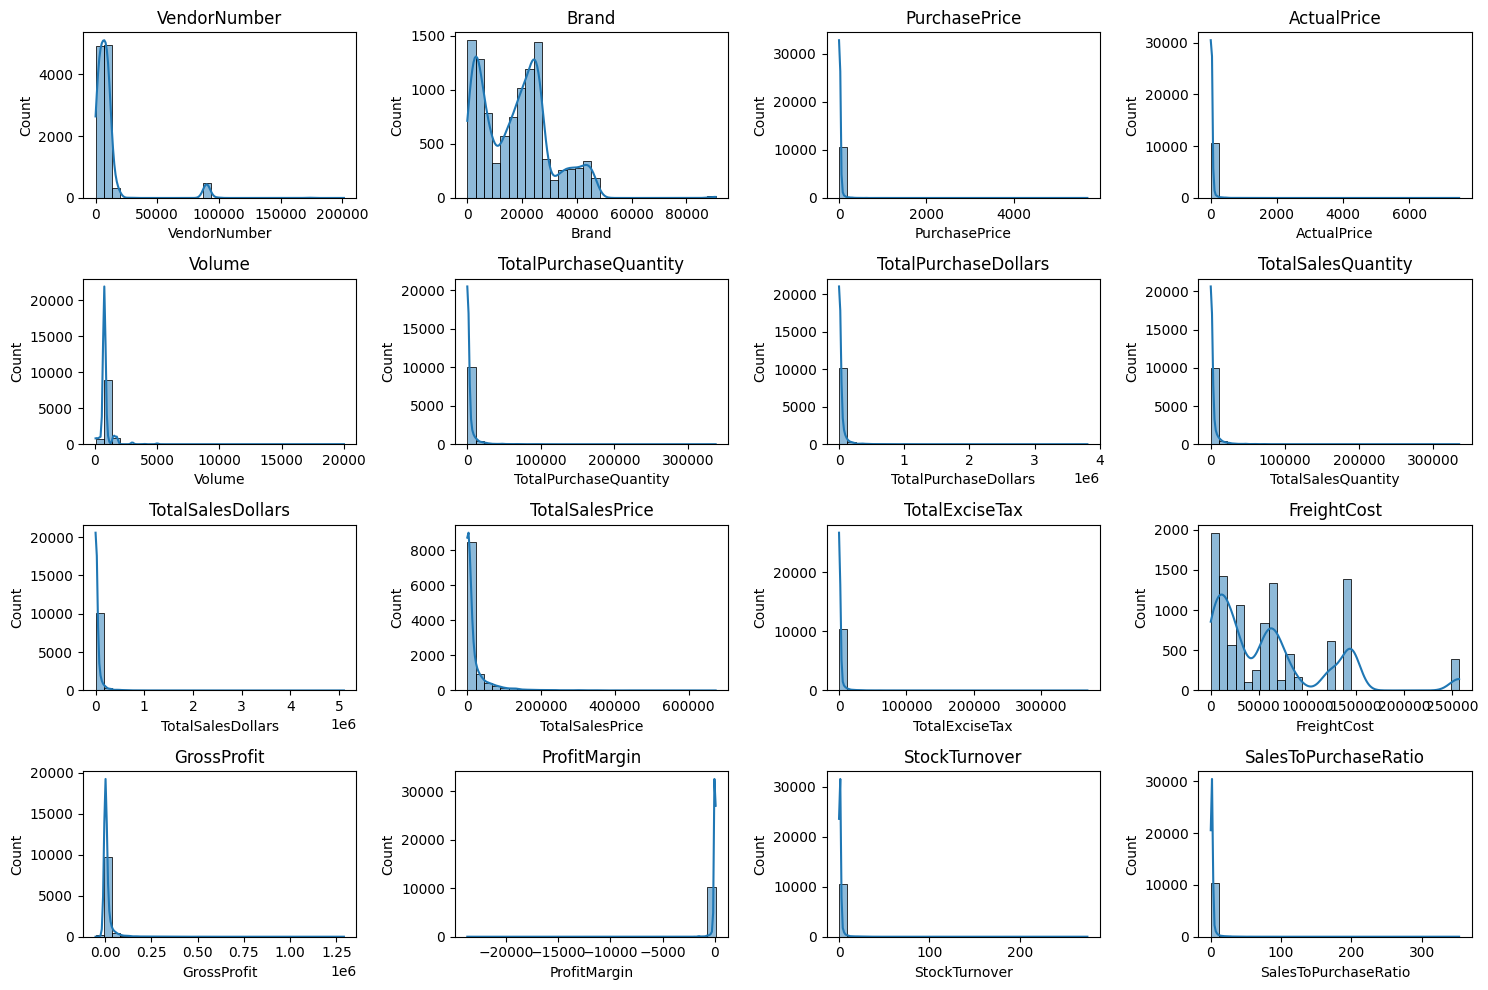

In [62]:
# Distribution Plots for
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10)) 
for i, col in enumerate(numerical_cols): 
    plt.subplot(4, 4, i+1) # Adjust grid layout as needed 
    sns.histplot(df[col], kde=True, bins=30) 
    plt.title(col) 
plt.tight_layout() 
plt.show()



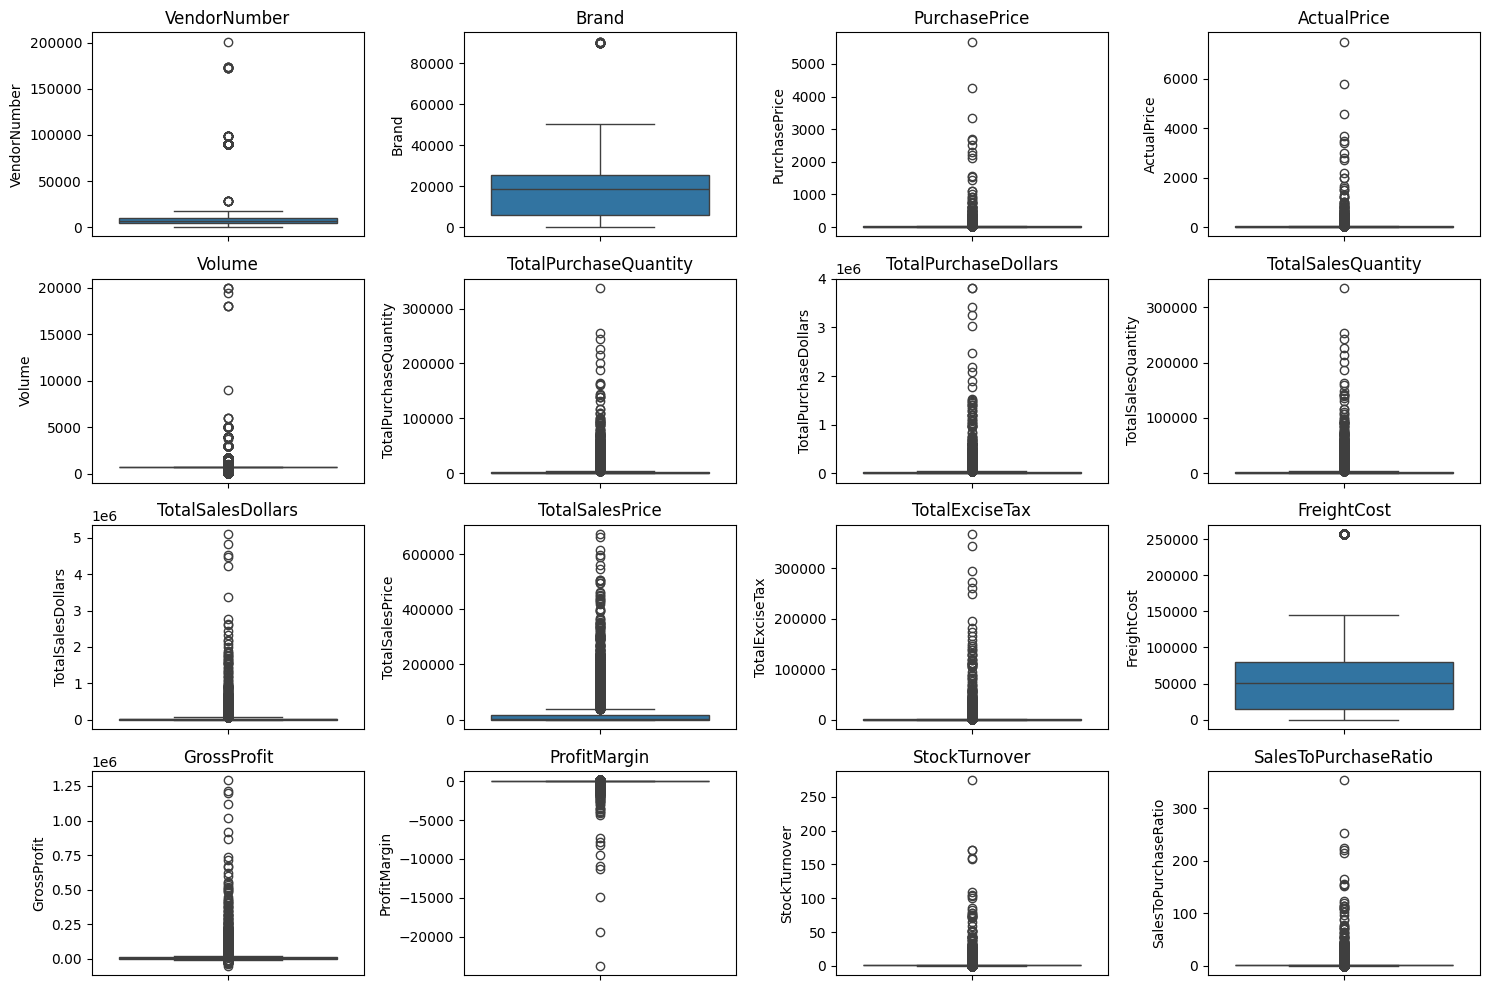

In [63]:
# Outlier Detection with Boxplots 
plt.figure(figsize=(15, 10)) 
for i, col in enumerate(numerical_cols): 
    plt.subplot(4, 4, i+1) 
    sns.boxplot(y=df[col]) 
    plt.title(col)
    plt.tight_layout()
plt.show()

In [64]:
# let's filter the data by removing inconsistencies 
df = pd.read_sql_query("""SELECT * 
FROM vendor_sales_summary 
WHERE GrossProfit > 0 
AND ProfitMargin > 0 
AND TotalSalesQuantity > 0""",conn)

In [65]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667
8560,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829
8561,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.98,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838
8562,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,143.28,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388


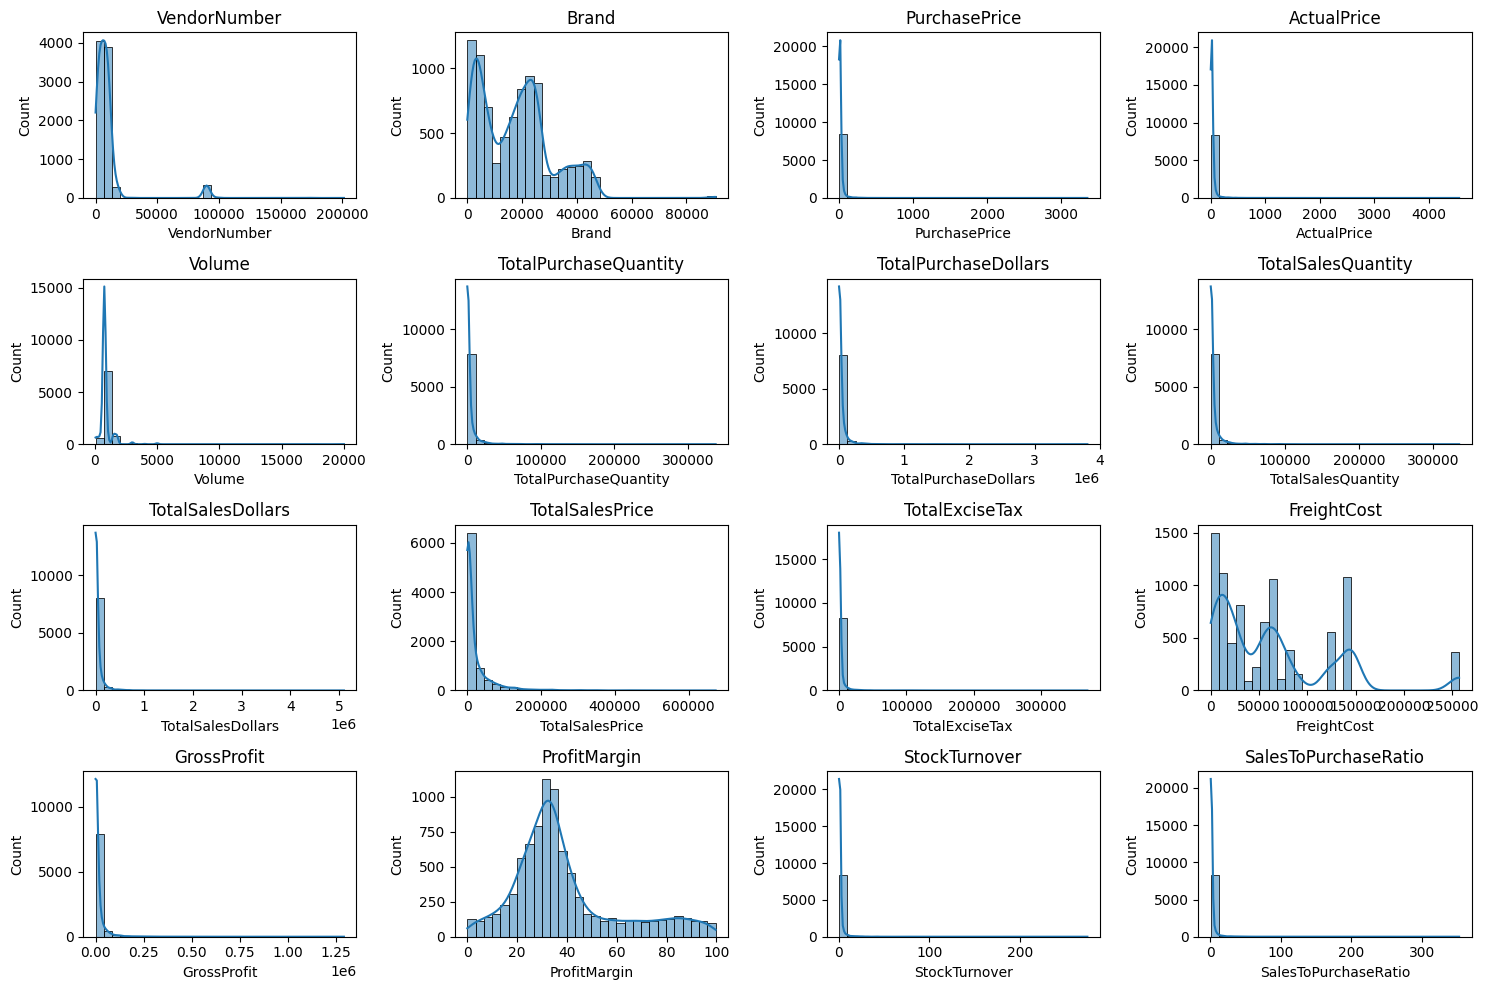

In [66]:
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10)) 
for i, col in enumerate(numerical_cols): 
    plt.subplot(4, 4, i+1) # Adjust grid layout as needed 
    sns.histplot(df[col], kde=True, bins=30) 
    plt.title(col) 
plt.tight_layout() 
plt.show()

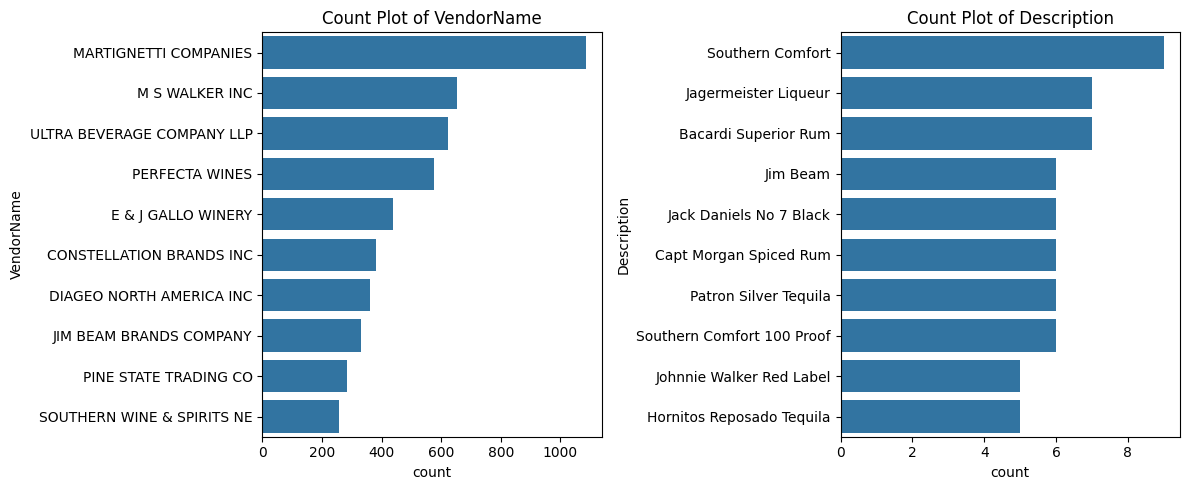

In [67]:
# Count Plots for Categorical Columns 
categorical_cols = ["VendorName", "Description"] 
plt.figure(figsize=(12,5)) 
for i, col in enumerate(categorical_cols): 
    plt.subplot(1, 2, i+1) 
    sns.countplot(y=df [col], order=df [col].value_counts(). index [:10]) # Top 10 categories 
    plt.title(f"Count Plot of {col}") 
plt.tight_layout()
plt.show()



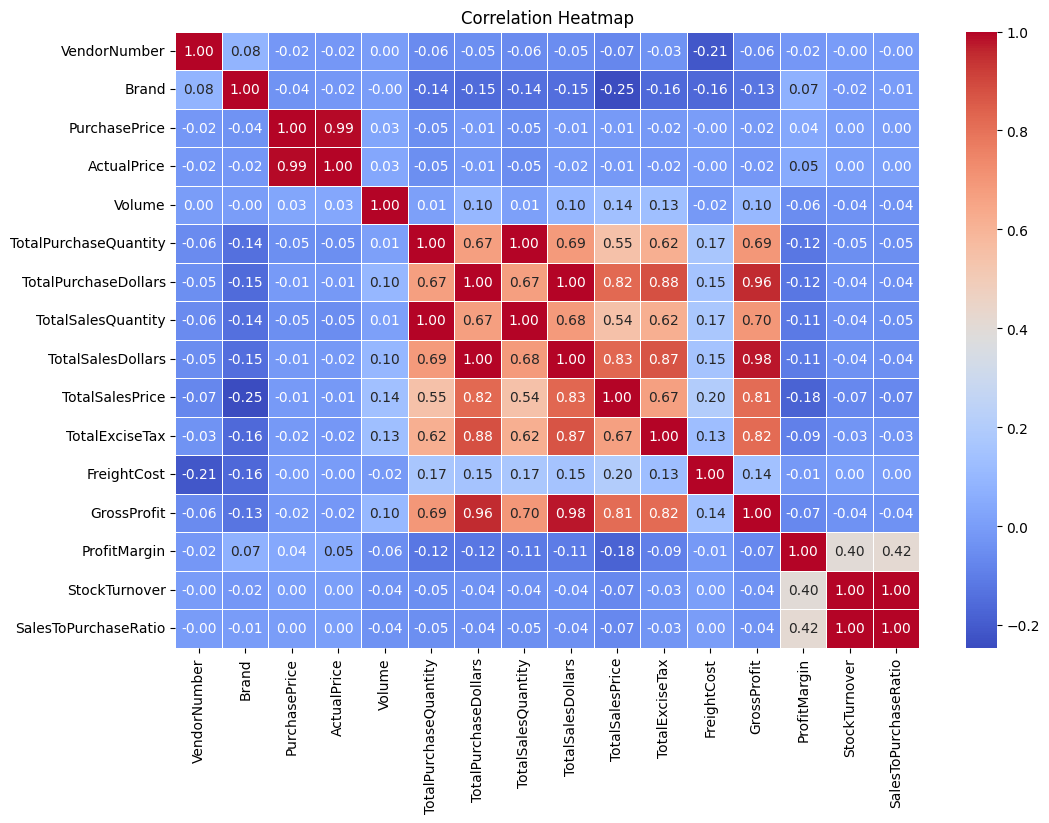

In [68]:
# Correlation Heatmap 
plt.figure(figsize=(12,8)) 
correlation_matrix = df [numerical_cols].corr() 
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5) 
plt.title("Correlation Heatmap") 
plt.show()

**Identify Brands that needs Promotional or Pricing Adjustments which exhibit lower sales performance but higher profit margins.**

In [69]:
df.groupby('Description' ). agg({ 
    'TotalSalesDollars':'sum', 
    'ProfitMargin': 'mean'})

,TotalSalesDollars,ProfitMargin
Description,,
(RI) 1,21519.09,18.060661
.nparalleled Svgn Blanc,1094.63,29.978166
10 Span Cab Svgn CC,2703.89,20.937612
10 Span Chard CC,3325.56,27.806445
10 Span Pnt Gris Monterey Cy,2082.22,32.226182
...,...,...
Zorvino Vyds Sangiovese,10579.03,29.525675
Zuccardi Q Malbec,1639.18,23.981503
Zum Rsl,10857.34,32.675038


In [70]:
brand_performance = df.groupby('Description' ). agg({ 
    'TotalSalesDollars':'sum', 
    'ProfitMargin': 'mean'}).reset_index()

In [71]:
low_sales_threshold = brand_performance ['TotalSalesDollars'].quantile(0.15) 
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)

In [72]:
low_sales_threshold, high_margin_threshold

(np.float64(560.299), np.float64(64.97017552750113))

In [73]:
brand_performance = brand_performance [brand_performance ['TotalSalesDollars' ]<10000] # for better visualization

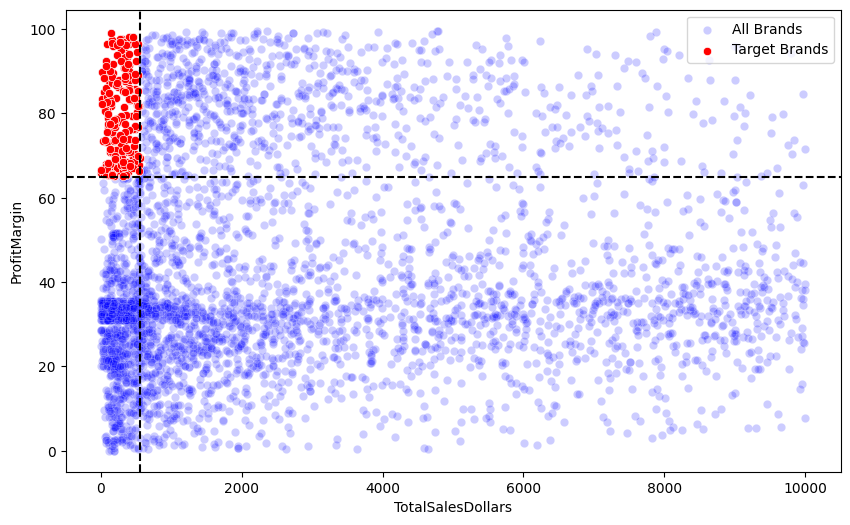

In [74]:
# Define target_brands based on your thresholds before plotting
target_brands = brand_performance[
    (brand_performance['ProfitMargin'] > high_margin_threshold) & 
    (brand_performance['TotalSalesDollars'] < low_sales_threshold)
]

plt.figure(figsize=(10, 6))  
sns.scatterplot(data=brand_performance, x='TotalSalesDollars', y='ProfitMargin', color="blue", label="All Brands", alpha=0.2) 
sns.scatterplot(data=target_brands, x='TotalSalesDollars', y='ProfitMargin', color="red", label="Target Brands") 
plt.axhline(high_margin_threshold, linestyle='--', color='black', label="High Margin Threshold") 
plt.axvline(low_sales_threshold, linestyle='--', color='black', label="Low Sales Threshold")

**Which vendors and brands demonstrate the highest sales performance? 1**

In [75]:
# Top Vendors & Brands by Sales Performance 
top_vendors = df.groupby("VendorName") ["TotalSalesDollars"].sum().nlargest(10) 
top_brands = df.groupby("Description") ["TotalSalesDollars"].sum().nlargest(10) 
top_vendors

VendorName
DIAGEO NORTH AMERICA INC      67990099.42
MARTIGNETTI COMPANIES         39330359.36
PERNOD RICARD USA             32063196.19
JIM BEAM BRANDS COMPANY       31423020.46
BACARDI USA INC               24854817.14
CONSTELLATION BRANDS INC      24218745.65
E & J GALLO WINERY            18399899.46
BROWN-FORMAN CORP             18247230.65
ULTRA BEVERAGE COMPANY LLP    16502544.31
M S WALKER INC                14706458.51
Name: TotalSalesDollars, dtype: float64

In [76]:
top_brands.apply(lambda x : format_dollars(x))

Description
Jack Daniels No 7 Black    $7,964,746.76
Tito's Handmade Vodka      $7,399,657.58
Grey Goose Vodka           $7,209,608.06
Capt Morgan Spiced Rum     $6,356,320.62
Absolut 80 Proof           $6,244,752.03
Jameson Irish Whiskey      $5,715,759.69
Ketel One Vodka            $5,070,083.56
Baileys Irish Cream        $4,150,122.07
Kahlua                     $3,604,858.66
Tanqueray                  $3,456,697.90
Name: TotalSalesDollars, dtype: object

In [54]:
# 1. Define the missing function
def format_dollars(x):
    try:
        # Formats the number with a dollar sign, commas, and 2 decimal places
        return f"${float(x):,.2f}"
    except (ValueError, TypeError):
        # If the value is text (like a brand name) or missing, leave it alone
        return x

# 2. Apply it to your data (make sure to assign it back to a variable)
top_brands_formatted = top_brands.apply(lambda x: format_dollars(x))

In [55]:
top_brands_formatted

Description
Jack Daniels No 7 Black    $7,964,746.76
Tito's Handmade Vodka      $7,399,657.58
Grey Goose Vodka           $7,209,608.06
Capt Morgan Spiced Rum     $6,356,320.62
Absolut 80 Proof           $6,244,752.03
Jameson Irish Whiskey      $5,715,759.69
Ketel One Vodka            $5,070,083.56
Baileys Irish Cream        $4,150,122.07
Kahlua                     $3,604,858.66
Tanqueray                  $3,456,697.90
Name: TotalSalesDollars, dtype: object

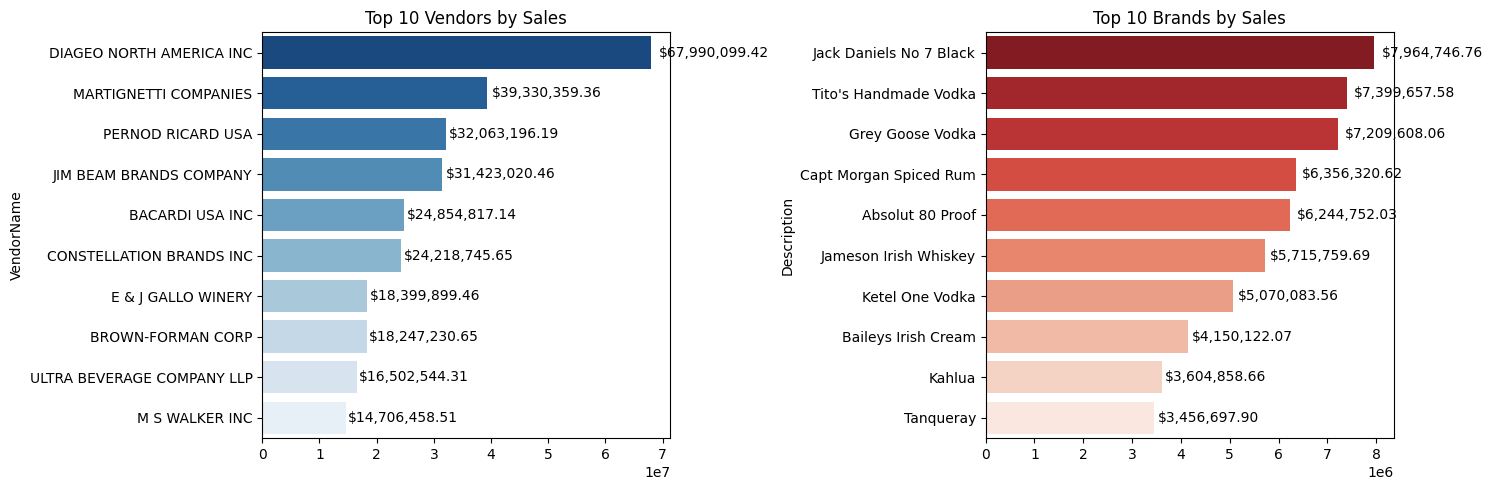

In [79]:
plt.figure(figsize=(15,5))

 # Plot for Top Vendors   
plt.subplot(1, 2, 1) 
ax1 = sns.barplot(y=top_vendors.index, x=top_vendors.values, palette="Blues_r") 
plt.title("Top 10 Vendors by Sales") 

for bar in ax1.patches: 
    ax1.text(bar.get_width()+(bar.get_width() * 0.02), 
    bar.get_y() + bar.get_height() / 2, 
    format_dollars(bar.get_width()), 
    ha='left', va='center', 
    fontsize=10, 
    color='black')


# Plot for Top Brands 
plt.subplot(1, 2, 2) 
ax2 = sns.barplot(y=top_brands. index.astype(str), x=top_brands.values, palette="Reds_r") 
plt.title("Top 10 Brands by Sales")

for bar in ax2.patches: 
    ax2.text(bar.get_width()+(bar.get_width() * 0.02), 
    bar.get_y() + bar.get_height() / 2, 
    format_dollars(bar.get_width()), 
    ha='left', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()

**Which vendors contribute the most to total purchase dollars?**

In [82]:
vendor_performance = df.groupby('VendorName').agg({ 
    'TotalPurchaseDollars':'sum', 
    'GrossProfit':'sum', 
    'TotalSalesDollars':'sum' }).reset_index()

In [84]:
vendor_performance.reset_index()

,index,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars
0,0,ADAMBA IMPORTS INTL INC,446.16,258.37,704.53
1,1,ALISA CARR BEVERAGES,25698.12,78772.82,104470.94
2,2,ALTAMAR BRANDS LLC,11706.20,4000.61,15706.81
3,3,AMERICAN SPIRITS EXCHANGE,934.08,577.08,1511.16
4,4,AMERICAN VINTAGE BEVERAGE,104435.68,35167.85,139603.53
...,...,...,...,...,...
114,114,WEIN BAUER INC,42694.64,13522.49,56217.13
115,115,WESTERN SPIRITS BEVERAGE CO,298416.86,106837.97,405254.83
116,116,WILLIAM GRANT & SONS INC,5876538.26,1693337.94,7569876.20
117,117,WINE GROUP INC,5203801.17,3100242.11,8304043.28


In [110]:
vendor_performance ['PurchaseConribution%' ] = vendor_performance ['TotalPurchaseDollars']/ vendor_performance ['TotalPurchaseDollars'].sum()*100

In [111]:
vendor_performance = round(vendor_performance.sort_values('PurchaseConribution%', ascending=False), 2)    

In [112]:
# Display Top 10 Vendors
top_vendors = vendor_performance.head(10)
top_vendors ['TotalSalesDollars' ] = top_vendors ['TotalSalesDollars'].apply(format_dollars)
top_vendors ['TotalPurchaseDollars' ] = top_vendors ['TotalPurchaseDollars']. apply(format_dollars)
top_vendors ['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)
top_vendors

top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseConribution%
25,DIAGEO NORTH AMERICA INC,"$50,097,226.16","$17,892,873.26","$67,990,099.42",16.30
57,MARTIGNETTI COMPANIES,"$25,502,095.83","$13,828,263.53","$39,330,359.36",8.30
68,PERNOD RICARD USA,"$23,851,164.17","$8,212,032.02","$32,063,196.19",7.76
46,JIM BEAM BRANDS COMPANY,"$23,494,304.32","$7,928,716.14","$31,423,020.46",7.64
6,BACARDI USA INC,"$17,432,020.26","$7,422,796.88","$24,854,817.14",5.67
20,CONSTELLATION BRANDS INC,"$15,273,708.08","$8,945,037.57","$24,218,745.65",4.97
11,BROWN-FORMAN CORP,"$13,238,939.18","$5,008,291.47","$18,247,230.65",4.31
30,E & J GALLO WINERY,"$12,068,539.22","$6,331,360.24","$18,399,899.46",3.93
106,ULTRA BEVERAGE COMPANY LLP,"$11,167,081.61","$5,335,462.70","$16,502,544.31",3.63
53,M S WALKER INC,"$9,764,312.60","$4,942,145.91","$14,706,458.51",3.18


In [113]:
vendor_performance.shape

(119, 5)

In [103]:
print(top_vendors.columns.tolist())

['VendorName', 'TotalPurchaseDollars', 'GrossProfit', 'TotalSalesDollars', 'PurchaseConribution%']


In [114]:
top_vendors['PurchaseConribution%'].sum()

np.float64(65.69000000000001)

In [115]:
top_vendors['Cumulative_Contribution%'] = top_vendors['PurchaseConribution%'].cumsum() 
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseConribution%,Cumulative_Contribution%
25,DIAGEO NORTH AMERICA INC,"$50,097,226.16","$17,892,873.26","$67,990,099.42",16.30,16.30
57,MARTIGNETTI COMPANIES,"$25,502,095.83","$13,828,263.53","$39,330,359.36",8.30,24.60
68,PERNOD RICARD USA,"$23,851,164.17","$8,212,032.02","$32,063,196.19",7.76,32.36
46,JIM BEAM BRANDS COMPANY,"$23,494,304.32","$7,928,716.14","$31,423,020.46",7.64,40.00
6,BACARDI USA INC,"$17,432,020.26","$7,422,796.88","$24,854,817.14",5.67,45.67
20,CONSTELLATION BRANDS INC,"$15,273,708.08","$8,945,037.57","$24,218,745.65",4.97,50.64
11,BROWN-FORMAN CORP,"$13,238,939.18","$5,008,291.47","$18,247,230.65",4.31,54.95
30,E & J GALLO WINERY,"$12,068,539.22","$6,331,360.24","$18,399,899.46",3.93,58.88
106,ULTRA BEVERAGE COMPANY LLP,"$11,167,081.61","$5,335,462.70","$16,502,544.31",3.63,62.51
53,M S WALKER INC,"$9,764,312.60","$4,942,145.91","$14,706,458.51",3.18,65.69


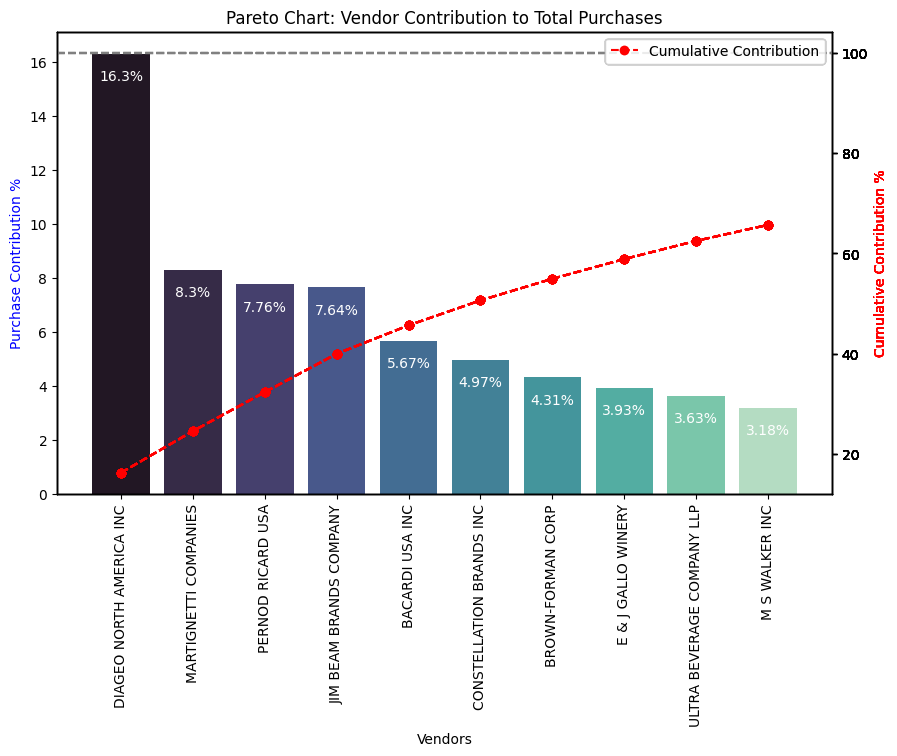

In [119]:
fig, ax1 =plt.subplots(figsize=(10,6))

# Bar plot for Purchase Contribution% 
sns.barplot(x=top_vendors['VendorName' ], y=top_vendors ['PurchaseConribution%'], palette="mako", ax=ax1) 

for i, value in enumerate(top_vendors ['PurchaseConribution%']): 
    ax1.text(i, value - 1, str(value)+'%', ha='center', fontsize=10, color='white') # Line Plot for Cumulative Contribution% 
    ax2 =ax1.twinx() 
    ax2.plot(top_vendors ['VendorName' ], 
    top_vendors ['Cumulative_Contribution%' ], 
    color='red', marker='o', linestyle='dashed', 
    label='Cumulative Contribution') 
    ax1.set_xticklabels(top_vendors ['VendorName'], rotation=90) 

    ax1.set_ylabel('Purchase Contribution %', color='blue' ) 

    ax2.set_ylabel('Cumulative Contribution %', color='red') 
    ax1.set_xlabel('Vendors') 
    ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases') 

    ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7) 
    ax2. legend(loc='upper right' )

plt.show()

**How much of total procurement is dependent on the top vendors?**

In [121]:
print(f"Total Purchase Contribution of top 10 vendors is {round(top_vendors['PurchaseConribution%'].sum(),2) } %")

Total Purchase Contribution of top 10 vendors is 65.69 %


ValueError: Format specifier missing precision

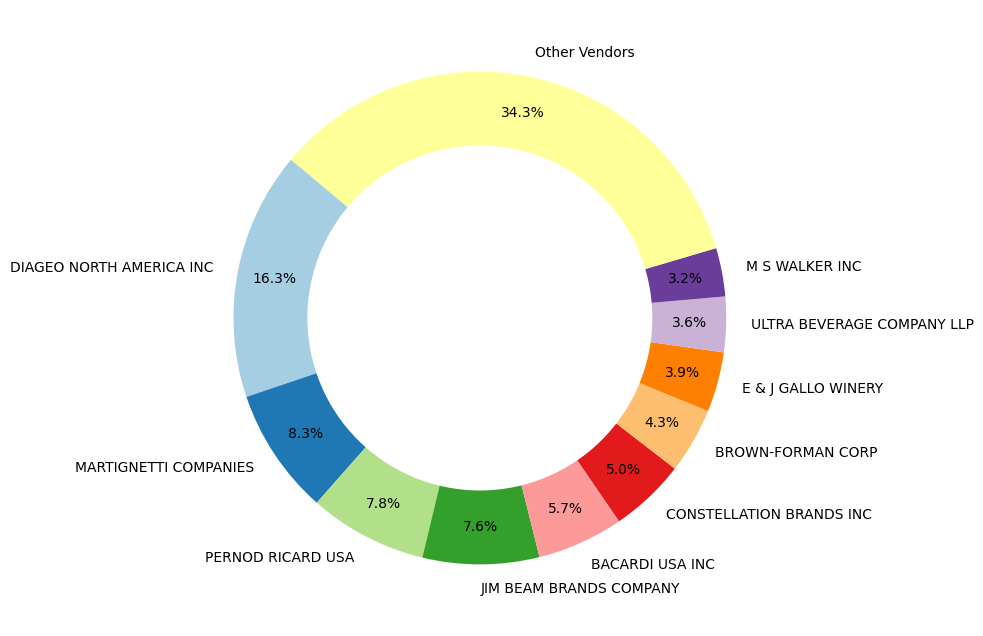

In [122]:
vendors = list(top_vendors ['VendorName' ].values) 
purchase_contributions = list(top_vendors['PurchaseConribution%'].values) 
total_contribution = sum(purchase_contributions) 
remaining_contribution = 100 - total_contribution


# Append "Other Vendors" category 
vendors.append("Other Vendors") 
purchase_contributions. append(remaining_contribution) 

# Donut Chart 
fig, ax = plt.subplots(figsize=(8,8)) 
wedges, texts, autotexts = ax.pie(purchase_contributions, 
labels=vendors, autopct='%1.1f%%', 
startangle=140, pctdistance=0.85, 
colors=plt.cm.Paired.colors)

# Draw a white circle in the center to create a "donut" effect 
centre_circle = plt.Circle((0, 0), 0.70, fc='white') 
fig.gca().add_artist(centre_circle)

# Add Total Contribution annotation in the center 
plt.text(0, 0, f"Top 10 Total:\n{total_contribution :. 2f}%", fontsize=14, fontweight='bold', ha='center', va='center' )

plt.title("Top 10 Vendor's Purchase Contribution (%)") 
plt.show()

**Does purchasing in bulk reduce the unit price, and what is the optimal purchase volume for cost savings?**

In [124]:
df ['UnitPurchasePrice' ] = df ['TotalPurchaseDollars'] / df ['TotalPurchaseQuantity' ]

In [125]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio,UnitPurchasePrice
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647,26.27
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830,23.19
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594,18.24
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493,16.17
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897,21.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667,1.32
8560,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829,0.39
8561,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.98,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838,0.74
8562,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,143.28,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388,1.47


In [127]:
df["OrderSize"] = pd.qcut(df["TotalPurchaseQuantity"], q=3, labels=["Small", "Medium", "Large"])
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio,UnitPurchasePrice,OrderSize
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647,26.27,Large
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830,23.19,Large
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594,18.24,Large
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493,16.17,Large
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897,21.89,Large
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667,1.32,Small
8560,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829,0.39,Small
8561,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.98,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838,0.74,Small
8562,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,143.28,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388,1.47,Small


In [129]:
df['OrderSize']

0       Large
1       Large
2       Large
3       Large
4       Large
        ...  
8559    Small
8560    Small
8561    Small
8562    Small
8563    Small
Name: OrderSize, Length: 8564, dtype: category
Categories (3, object): ['Small' < 'Medium' < 'Large']

In [130]:
df["OrderSize"] = pd.qcut(df["TotalPurchaseQuantity"], q=3, labels=["Small", "Medium", "Large"])

In [131]:
df.groupby('OrderSize') [['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,39.068186
Medium,15.486414
Large,10.777625


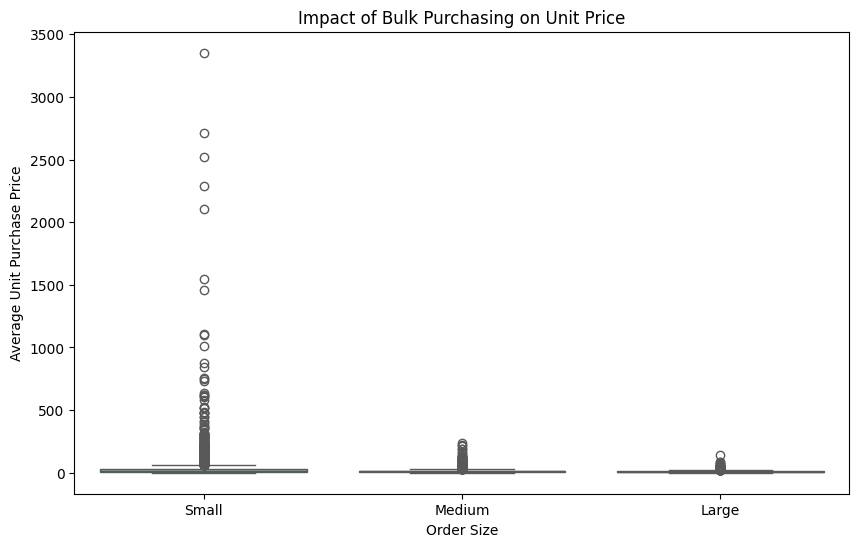

In [132]:
plt.figure(figsize=(10,6))  
sns.boxplot(data=df, x="OrderSize", y="UnitPurchasePrice", palette="Set2") 
plt.title("Impact of Bulk Purchasing on Unit Price") 
plt.xlabel("Order Size") 
plt.ylabel("Average Unit Purchase Price") 
plt.show()

**Which vendors have low inventory turnover, indicating excess stock and slow-moving products?**

In [136]:
df [df ['StockTurnover' ]<1].groupby('VendorName' ) [ ['StockTurnover' ]]. mean ( ).sort_values('StockTurnover', ascending=True).head(10)

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
CENTEUR IMPORTS LLC,0.773953
SMOKY QUARTZ DISTILLERY LLC,0.783835
TAMWORTH DISTILLING,0.797078
THE IMPORTED GRAPE LLC,0.807569


**How much capital is locked in unsold inventory per vendor, and which vendors contribute the most to it?**

In [137]:
df["UnsoldInventoryValue"] = (df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"]) * df ["PurchasePrice"] 
print('Total Unsold Capital:', format_dollars(df["UnsoldInventoryValue"].sum() ))

Total Unsold Capital: $2,708,177.22


In [138]:
# Aggregate Capital Locked per Vendor 
inventory_value_per_vendor = df.groupby("VendorName") ["UnsoldInventoryValue"].sum().reset_index()

# Sort Vendors with the Highest Locked Capital 

inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue", ascending=False) 
inventory_value_per_vendor ['UnsoldInventoryValue'] = inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_dollars) 
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,"$722,209.05"
46,JIM BEAM BRANDS COMPANY,"$554,665.63"
68,PERNOD RICARD USA,"$470,625.61"
116,WILLIAM GRANT & SONS INC,"$401,960.83"
30,E & J GALLO WINERY,"$228,282.61"
79,SAZERAC CO INC,"$198,436.41"
11,BROWN-FORMAN CORP,"$177,733.74"
20,CONSTELLATION BRANDS INC,"$133,617.62"
61,MOET HENNESSY USA INC,"$126,477.70"
77,REMY COINTREAU USA INC,"$118,598.15"


**What is the 95% confidence intervals for profit margins of top-performing and low-performing vendors.**

In [139]:
top_threshold = df ["TotalSalesDollars"].quantile(0.75) 
low_threshold = df["TotalSalesDollars"].quantile(0.25)

In [140]:
top_vendors = df[df["TotalSalesDollars"] >= top_threshold] ["ProfitMargin"].dropna() 
low_vendors = df[df["TotalSalesDollars"] <= low_threshold] ["ProfitMargin"].dropna()

In [141]:
top_vendors

0       25.297693
1       21.062810
2       24.675786
3       27.139908
4       28.412764
          ...    
3523    79.684817
3681    85.782102
4751    93.085860
4920    95.012530
5050    94.271857
Name: ProfitMargin, Length: 2141, dtype: float64

In [142]:
low_vendors

5631     4.111764
5652     6.145626
5701    12.007271
5704     1.677308
5724     7.239599
          ...    
8559    83.448276
8560    96.436186
8561    25.252525
8562    98.974037
8563    99.166079
Name: ProfitMargin, Length: 2141, dtype: float64

In [145]:
def confidence_interval(data, confidence=0.95): 
    mean_val = np.mean(data) 
    std_err = np.std(data, ddof=1) / np.sqrt(len(data)) # Standard error 
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) -1) 
    margin_of_error = t_critical * std_err 
    mean_val + margin_of_error
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

In [ ]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors) 
low_mean, low_lower, low_upper = confidence_interval(low_vendors) 

print(f"Top Vendors 95% CI: ({top_lower :.2f}, {top_upper :.2f}), Mean: {top_mean :. 2f}") 
print(f"Low Vendors 95% CI: ({low_lower :.2f}, {low_upper :.2f}), Mean: {low_mean :. 2f}") 
plt.figure(figsize=(12,6)) 

# Top Vendors Plot 
# 
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors") 
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower :. 2f}") 
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper :. 2f}") 
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean :. 2f}") 

# Low Vendors 

sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors") 
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower :. 2f}") 
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper :. 2f}") 
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean :. 2f}")


# Finalize Plot 
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)") 
plt.xlabel("Profit Margin (%)") 
plt.ylabel("Frequency") 
plt.legend() 
plt.grid(True)

plt.show()

ValueError: Format specifier missing precision